# 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
import warnings
warnings.filterwarnings('ignore')
# LabelEncoder : Converts text categories to integer labels (0, 1, 2 …)
# OrdinalEncoder: Encodes categories respecting a specified order

In [ ]:
##   A Decision Tree is a supervised machine learning algorithm that splits data into branches based on feature conditions, forming a tree-like structure.
##  Each internal node = a decision rule on a feature.
##  Each branch       = outcome of that rule (True / False).
##  Each leaf node    = final predicted class label.
##   We want to predict whether a patient has heart disease (binary: Yes / No) based on clinical measurements. Decision Trees are interpretable — doctors can follow the rules — and handle both numerical and categorical data well.

In [3]:
pip install openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 3.8 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# TASK 1 — DATA PREPARATION

In [ ]:
file_path = "heart_disease.xlsx"
df = pd.read_excel(file_path, sheet_name='Heart_disease')
# pd.read_excel() reads the Excel file into a pandas DataFrame.
# sheet_name='Heart_disease' targets the data sheet (not the description sheet).

In [59]:
# df.shape returns (rows, columns) — quick check that all data loaded properly.
df.shape

(908, 13)

In [60]:
# df.head() shows the first 5 rows — confirms column names and sample values.
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [61]:
df.isna().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [8]:
df.duplicated().sum()

1

In [9]:
df.drop_duplicates(inplace=True, ignore_index=True)

In [11]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,907.000000,907.000000,907.000000,907.000000,845.000000,907.000000
mean,53.787211,133.412348,201.465270,135.976847,0.892308,1.007718
std,9.162016,20.405432,112.158285,26.813075,1.094092,1.144594
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.500000,120.000000,176.500000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [12]:
print(df['num'].value_counts())

num
0    399
1    265
2    108
3    107
4     28
Name: count, dtype: int64


# VISUALISATION 1 — Target Class Distribution (Bar Chart)

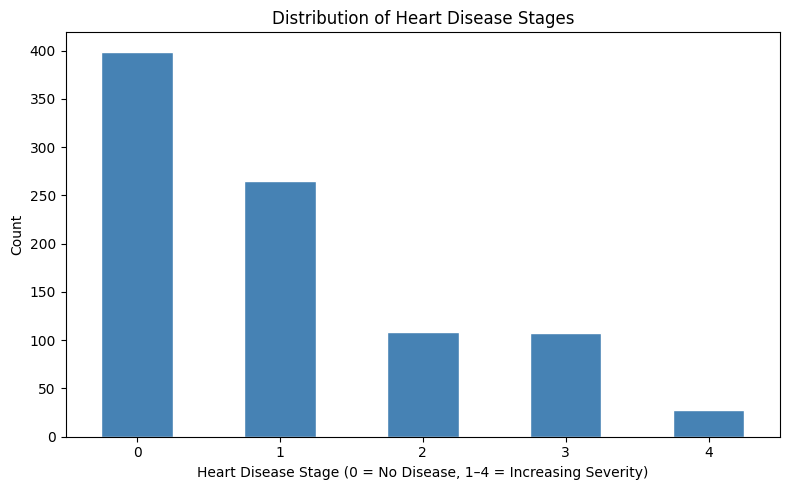

In [62]:
plt.figure(figsize=(8, 5))
df['num'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribution of Heart Disease Stages')
plt.xlabel('Heart Disease Stage (0 = No Disease, 1–4 = Increasing Severity)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# VISUALISATION 2 — Missing Value Heatmap

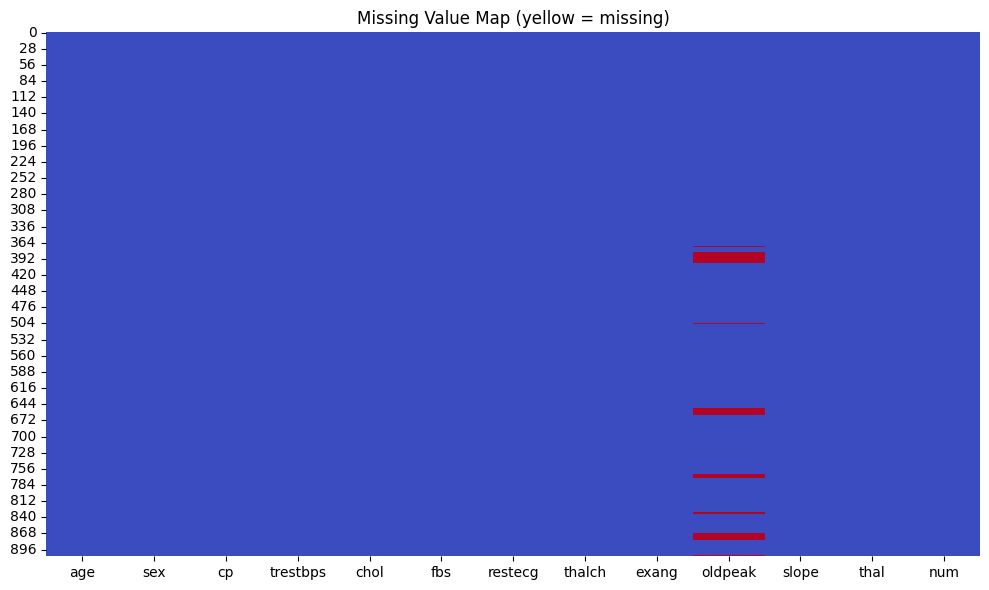

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), annot=False, cmap='coolwarm', cbar=False)
plt.title("Missing Value Map (yellow = missing)")
plt.tight_layout()
plt.show()
# A heatmap of df.isnull() visually highlights which cells are missing. Columns with many missing values appear as solid coloured bands,making the pattern of missingness immediately obvious.

# VISUALISATION 3 — Box Plots BEFORE Outlier Capping

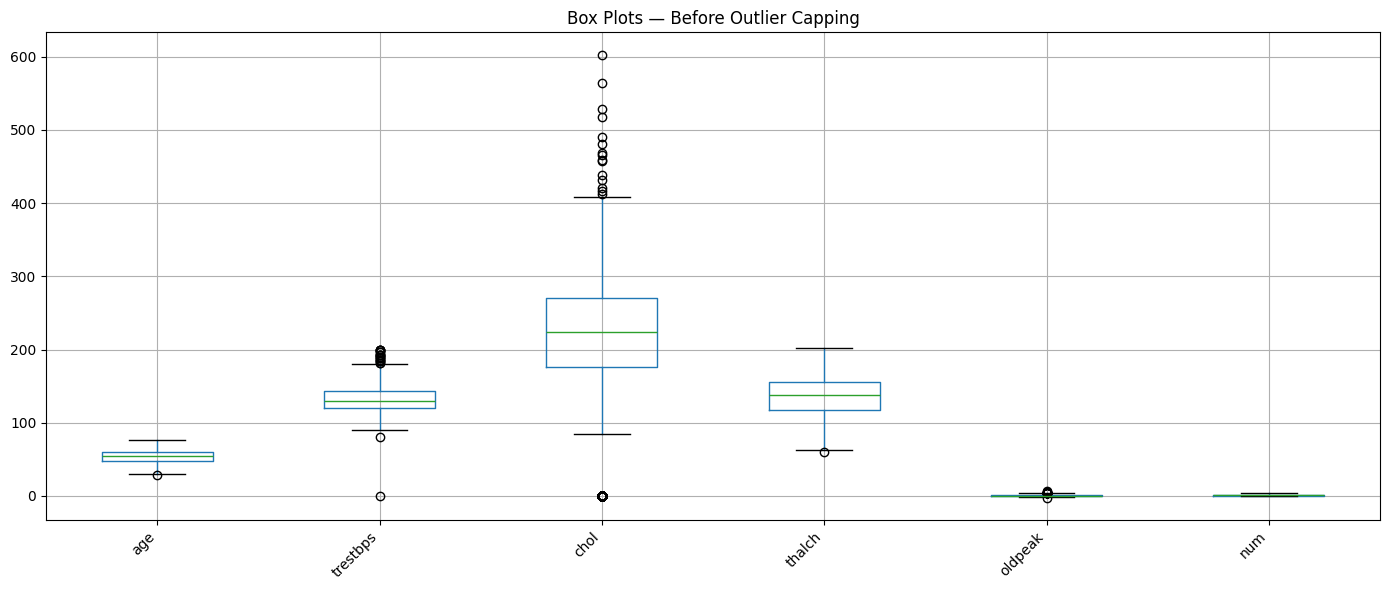

In [65]:
plt.figure(figsize=(14, 6))
df.select_dtypes(include=['int64', 'float64']).boxplot()
plt.title('Box Plots — Before Outlier Capping')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# OUTLIER CAPPING (IQR Method)

In [66]:
def outlier_capping(df, column):
    """
    Caps outliers in a single numerical column using the IQR method.
    Values below Q1 - 1.5*IQR are set to the lower fence.
    Values above Q3 + 1.5*IQR are set to the upper fence.
    """
    q1  = df[column].quantile(0.25)          # 25th percentile
    q3  = df[column].quantile(0.75)          # 75th percentile
    iqr = q3 - q1                            # Interquartile range
    lower_fence = q1 - 1.5 * iqr            # Minimum acceptable value
    upper_fence = q3 + 1.5 * iqr            # Maximum acceptable value
    # lambda clips each value to [lower_fence, upper_fence]
    df[column] = df[column].apply(
        lambda x: lower_fence if x < lower_fence
                  else upper_fence if x > upper_fence
                  else x
    )

# Apply capping to every integer and float column in the DataFrame.
# select_dtypes(['int','float']).columns → returns only numerical column names.
for col in df.select_dtypes(['int', 'float']).columns:
    outlier_capping(df, col)

# VISUALISATION 4 — Box Plots AFTER Outlier Capping

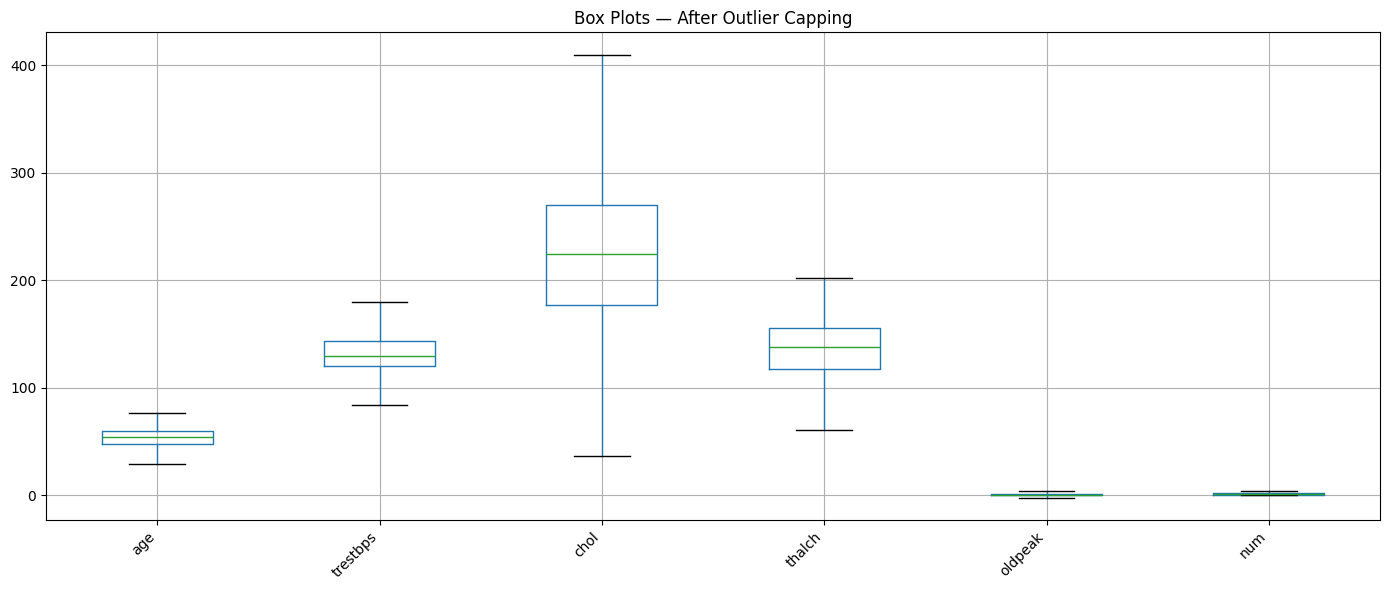

In [67]:
plt.figure(figsize=(14, 6))
df.select_dtypes(include=['int64', 'float64']).boxplot()
plt.title('Box Plots — After Outlier Capping')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Task 3 — Feature Engineering

In [68]:
# STEP 1 — Impute the one numerical column with missing values
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

In [ ]:
# STEP 2 — Encode categorical (text) columns to integers
label_encoders = {}
categorical_cols = ['sex', 'cp', 'restecg', 'slope', 'thal']

for col in categorical_cols:
    if col == 'thal':
        # Replace any erroneous placeholder entries with a valid random category
        thal_categories = ['reversable defect', 'normal', 'fixed defect']
        df['thal'] = df['thal'].apply(
            lambda x: np.random.choice(thal_categories) if 'CHOOSE' in str(x) else x
        )
    le = LabelEncoder()
    # astype(str) ensures any residual NaN objects become the string 'nan'
    # rather than causing a TypeError inside LabelEncoder.
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le   # store encoder in case inverse_transform is needed later

In [70]:
# STEP 3 — Fix boolean columns (fbs, exang)
def to_int_bool(col):
    return col.map(lambda x: 1 if str(x).strip().upper() in ('TRUE', '1', 'YES', 'TURE') else 0)

df['exang'] = to_int_bool(df['exang'])
df['fbs']   = to_int_bool(df['fbs'])

In [71]:
# STEP 4 — Final catch-all imputation
df.fillna(df.median(numeric_only=True), inplace=True)

In [72]:
# STEP 5 — Build feature matrix X and target vector y
features = df.drop("num", axis=1)   # X : all predictor columns
target   = df["num"]                # y : heart disease stage 0–4

In [75]:
# STEP 6 — Train / Test Split (80 % train, 20 % test)
x_train, x_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42)
# Confirm no text columns remain — sklearn cannot handle object dtype.
print("Object columns remaining:", x_train.select_dtypes(include='object').columns.tolist())
print(f"Train size: {x_train.shape}  |  Test size: {x_test.shape}")

Object columns remaining: []
Train size: (726, 12)  |  Test size: (182, 12)


In [76]:
# df.dtypes : final check that every column is now a numeric dtype.
# All object/bool columns should have been converted in the step above.
df.dtypes

age         float64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalch      float64
exang         int64
oldpeak     float64
slope         int64
thal          int64
num           int64
dtype: object

## Task 4 — Decision Tree Classification

In [77]:
# TASK 4 — Train a Default Decision Tree (no hyperparameter tuning yet)
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(x_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [78]:
y_pred = dt_classifier.predict(x_test)

In [79]:
# EVALUATION METRICS — Default Decision Tree
print("Decision Tree Performance (Default):")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred, average='weighted'):.4f}")

Decision Tree Performance (Default):
Accuracy  : 0.5000
Precision : 0.5105
Recall    : 0.5000
F1-Score  : 0.5040


# VISUALISATION 5 — Confusion Matrix (Default Tree)

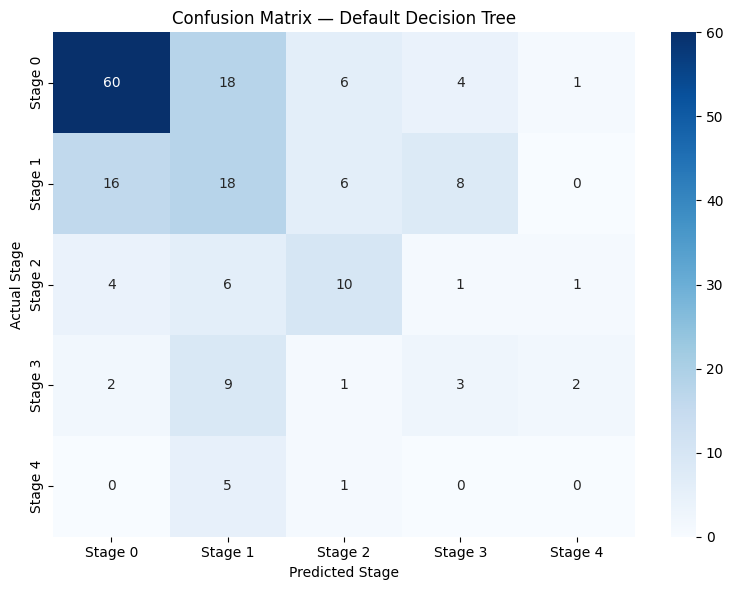

In [80]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Stage {i}' for i in range(cm.shape[1])],
            yticklabels=[f'Stage {i}' for i in range(cm.shape[0])])
plt.title('Confusion Matrix — Default Decision Tree')
plt.ylabel('Actual Stage')
plt.xlabel('Predicted Stage')
plt.tight_layout()
plt.show()

In [81]:
print(classification_report(y_test, y_pred,
      target_names=[f'Stage {i}' for i in range(5)]))

              precision    recall  f1-score   support

     Stage 0       0.73      0.67      0.70        89
     Stage 1       0.32      0.38      0.35        48
     Stage 2       0.42      0.45      0.43        22
     Stage 3       0.19      0.18      0.18        17
     Stage 4       0.00      0.00      0.00         6

    accuracy                           0.50       182
   macro avg       0.33      0.34      0.33       182
weighted avg       0.51      0.50      0.50       182



## Task 5 — Hyperparameter Tuning

In [82]:
param_grid = {
    'max_depth'        : [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf' : [1, 2, 5, 10],
    'criterion'        : ['gini', 'entropy']
}

In [83]:
# GridSearchCV — Exhaustive Search with Cross-Validation
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(x_train, y_train)


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [84]:
print("Best parameters        :", grid_search.best_params_)
print("Best CV accuracy score :", round(grid_search.best_score_, 4))

Best parameters        : {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV accuracy score : 0.5317


In [85]:
best_dt      = grid_search.best_estimator_
y_pred_best  = best_dt.predict(x_test)

In [86]:
# EVALUATION — Optimised Decision Tree
print("\nOptimised Decision Tree Performance:")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_best, average='weighted'):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_best, average='weighted'):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_best, average='weighted'):.4f}")


Optimised Decision Tree Performance:
Accuracy  : 0.5714
Precision : 0.4800
Recall    : 0.5714
F1-Score  : 0.5217


## Task 6 — Model Evaluation and Analysis

In [87]:
feature_importance = best_dt.feature_importances_
feature_names      = features.columns   

In [88]:
importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)


In [89]:
importance_df

,Feature,Importance
2,cp,0.566550
0,age,0.150569
4,chol,0.133364
8,exang,0.086743
3,trestbps,0.043988
9,oldpeak,0.018786
1,sex,0.000000
5,fbs,0.000000
6,restecg,0.000000
7,thalch,0.000000


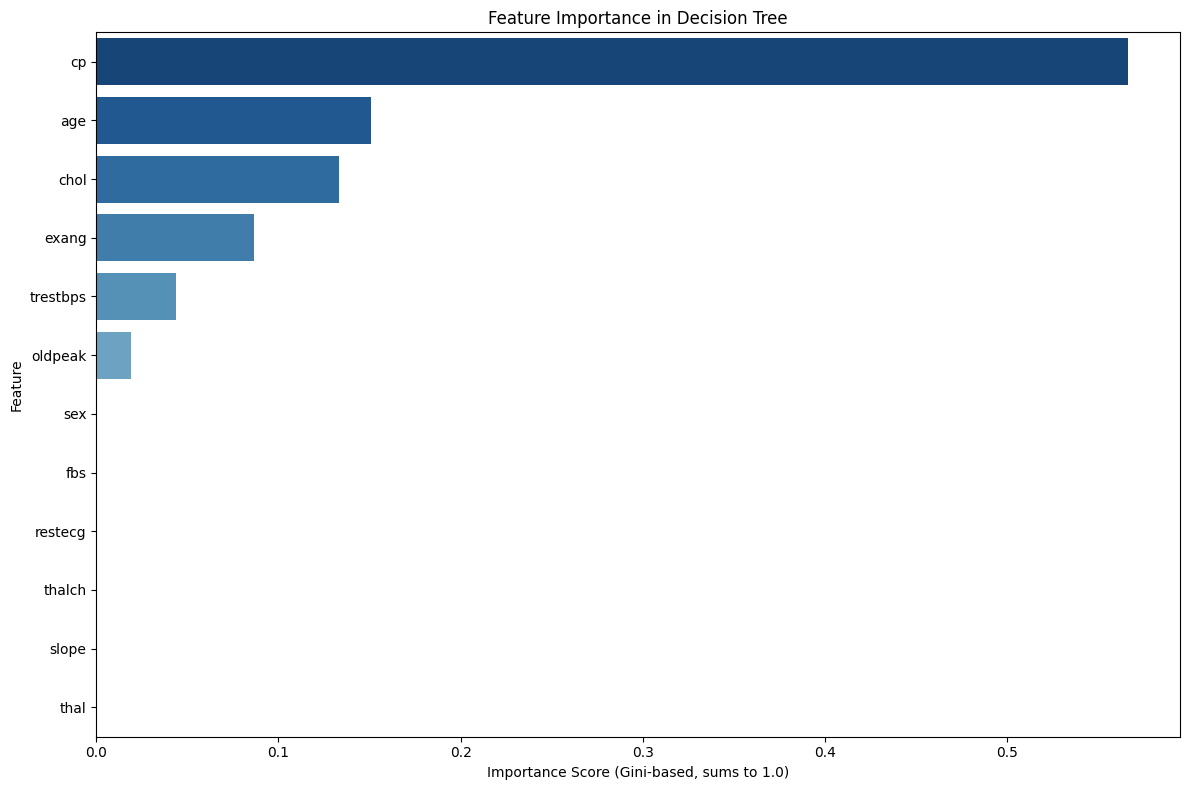

In [90]:
# VISUALISATION 6 — Feature Importance Bar Chart
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Blues_r')
plt.title('Feature Importance in Decision Tree')
plt.xlabel('Importance Score (Gini-based, sums to 1.0)')
plt.tight_layout()
plt.show()

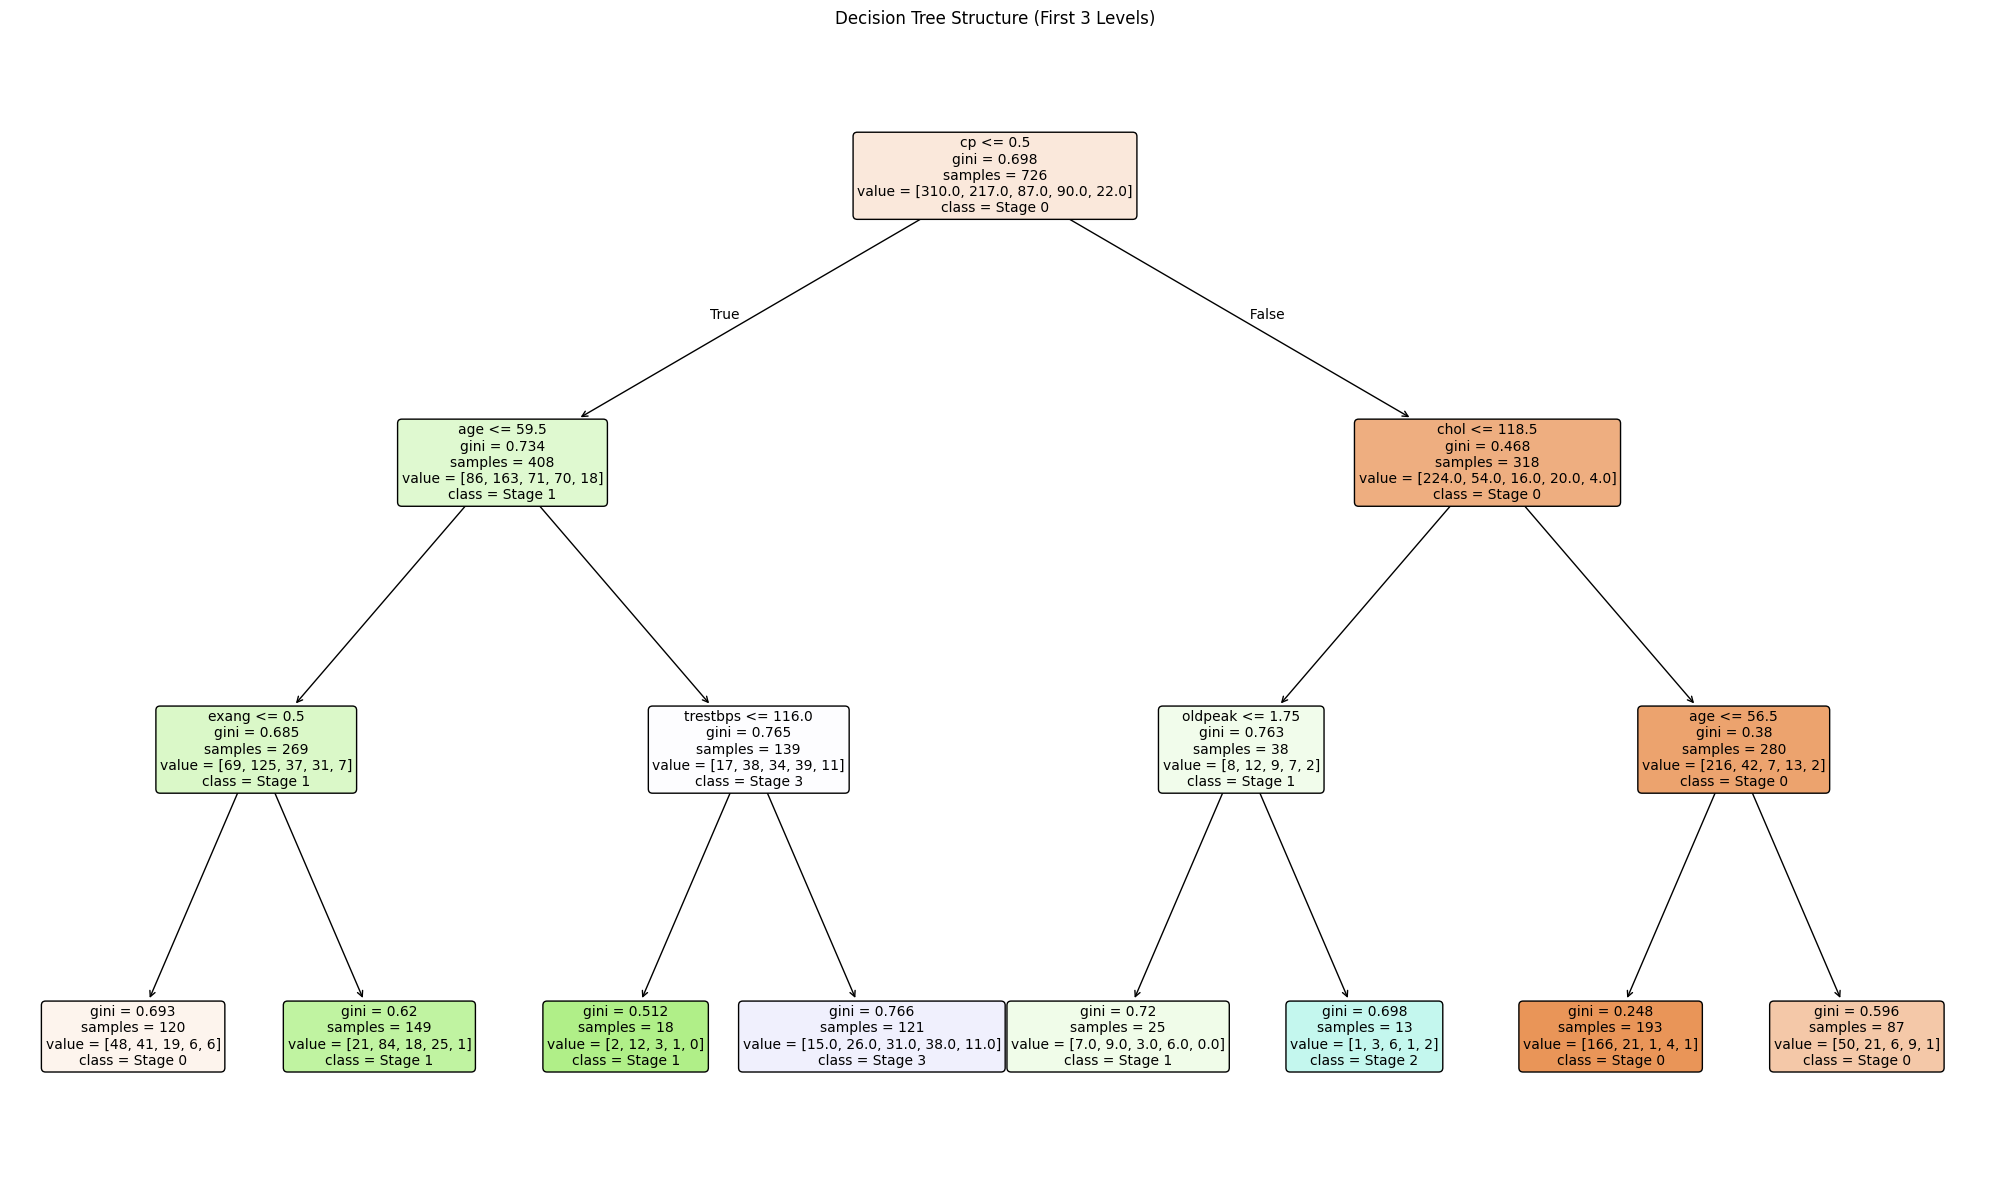

In [91]:
# VISUALISATION 7 — Decision Tree Structure (First 3 Levels)
plt.figure(figsize=(20, 12))
plot_tree(
    best_dt,
    feature_names=feature_names,
    class_names=[f'Stage {i}' for i in range(5)],   # 5 classes: stages 0–4
    filled=True,        # colour nodes by dominant class
    rounded=True,       # rounded corners for readability
    max_depth=3,        # show only top 3 levels to avoid visual clutter
    fontsize=10
)
plt.title('Decision Tree Structure (First 3 Levels)')
plt.tight_layout()
plt.show()

## Interview Questions

### Q1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

**max_depth** controls how deep the tree can grow. A low value keeps the tree shallow and simple, which can lead to underfitting. A very high value or None lets the tree grow until all leaves are pure, which often leads to overfitting.

**min_samples_split** sets the minimum number of samples a node must have before it can be split. Higher values mean fewer splits happen, making the tree simpler and less likely to overfit.

**min_samples_leaf** sets the minimum number of samples that must end up in a leaf node. This prevents very small, noisy leaves and acts as a smoothing effect on the model.

**criterion** decides how the quality of a split is measured. gini uses Gini Impurity and is faster to compute. entropy uses Information Gain and can be slightly more informative. In practice both give similar results.

**max_features** limits how many features are considered at each split. Using fewer features introduces randomness and helps reduce overfitting.

**max_leaf_nodes** puts a hard cap on the total number of leaves in the tree, limiting overall complexity and helping avoid overfitting.

**ccp_alpha** is a pruning parameter. After the tree is built, branches that add very little predictive value are removed. A larger value prunes more branches, resulting in a simpler and more generalisable tree.

### Q2. What is the difference between Label Encoding and One-Hot Encoding?

**Label Encoding** converts each category into a unique integer. For example, in the cp column, asymptomatic becomes 0, atypical angina becomes 1, non-anginal becomes 2, and typical angina becomes 3. It is best used for binary columns like sex or exang, or for ordinal columns where the categories have a natural order such as Low, Medium, High. The risk is that for unordered categories, the model may wrongly interpret the integers as having a meaningful numeric relationship.

**One-Hot Encoding** creates a separate binary column for each unique category value. Only the active category gets a 1 and all others get 0. For example, the cp column would become four separate columns. It is best used for nominal categories that have no natural order. The advantage is that no false ordering is assumed. The trade-off is that it increases the number of columns in the dataset, which can slow training when there are many unique categories.